In [1]:
%matplotlib ipympl
import glob 
import os 
import sys
import time 
import h5py 
import matplotlib.pylab as plt 
import numpy as np 
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar
import math
import matplotlib.cm as cm 
import datetime 
import pandas
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
style= 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction']=tick_dir
plt.rcParams['ytick.direction']=tick_dir
plt.rcParams['axes.linewidth']=1
plt.rcParams['font.size']=15
plt.rcParams['axes.grid']=True
plt.rcParams['grid.alpha']=0.5
plt.rcParams.update({"text.usetex":False, "font.family":"serif"})

In [4]:
## no need to run this cell -- 
files_patt="*.ipynb"
files=glob.glob(files_patt)

print(f"found {len(files)} files: {files}\n")

found 17 files: ['drone_publications_plots.ipynb', 'test_pocket_correlator_auto.ipynb', 'KBB_dns_corrdata_analysis_dronedata_final.ipynb', 'analyse_raw_adc-checkpoint.ipynb', 'KBB_dns_beamamprecovery_implement_chamberdata_final.ipynb', 'crs_corr_data_analysis.ipynb', 'dns_vdif_data_kbb.ipynb', 'crs_corr_anechoic_chamber_drone_data_analysis.ipynb', 'crs_corr_gbo_data_analysis_NWNE_first_grid.ipynb', 'Drone_Angle_Code.ipynb', 'chamber+bench_publication_plots.ipynb', 'autos&crosses_overlay.ipynb', 'KBB_dns_beamamprecovery_implement_dronedata_final.ipynb', 'drone_data_investigate.ipynb', 'check_adc_levels_Ian.ipynb', 'corr_data_noise_source_kbb.ipynb', 'KBB_dns_corrdata_analysis_chamberdata_final.ipynb']



## Defining functions to be used in the code 

In [3]:
# Small dishes or low frequencies create wide, blurry beams
def get_beam_fwhm(d=6.0, nu=600):
    fwhm=(3*1e8)/(nu*1e6)/d # lambda/d -- raw resolution 
    return np.rad2deg(fwhm*1.22)

#fwhm1=get_beam_fwhm(d=3,nu=800)
#print(f"fwhm is {fwhm1:.3f} deg")

In [4]:
def gaussian(x, a, mean, sigma):
    val = a*np.exp(-(x-mean)**2/(2* sigma**2))
    return val

#val1=gaussian(1,1,0,1) # 1-sigma spread at standard 60.6% 
#print(f"gaussian val is {val1}")

In [5]:
def seconds_to_degrees(seconds, declination=22.0145):
    """
        Converts seconds to degrees of sky motion at a latitude
        default TONE latitude -- default for crab.
    """
    return seconds*np.cos(np.deg2rad(declination))/240

#sec=240
#dec=22.0145 # look at how difference does it make when goes from 89 to 90
#deg1=seconds_to_degrees(sec, dec)
#print(f"In {sec} seconds, sky at declination of {dec} degrees drifted {deg1} degrees.")

In [6]:
class correlator_data:
    def __init__(self, vis, time, sat, index_map):
        self.vis = vis
        self.time = time
        self.sat = sat
        self.freq = index_map['freq'][:]
        self.prod = index_map['prod'][:]

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
       Reads, extracts, and combines data from a collection of HDF5 (.h5) files.
    """
    
    # Grab and sort files
    files = glob.glob(file_path + '*[!.lock]')
    files.sort()
    
    # Slice file list based on indices
    files = files[f_start:f_stop]
    
    vis_list = []
    time_list = []
    sat_list = []
    index_map_ref = None

    try:
        for x in files:
            print(f"Reading File: {x}")
            with h5py.File(x, 'r') as f:
                # Cache index_map from the first file or as needed
                if index_map_ref is None:
                    index_map_ref = f['index_map']
                    time_list.append(index_map_ref['time'][:])
                else:
                    time_list.append(index_map_ref['time'][:])
                
                vis_list.append(f['vis'][:])
                sat_list.append(f['sat'][:])
                print(f"Appended vis data and time stream from {x}")

        # Concatenate lists into final arrays 
        vis = np.concatenate(vis_list, axis=0)
        time = np.concatenate(time_list, axis=0)
        sat = np.concatenate(sat_list, axis=0)
        
        return correlator_data(vis, time, sat, index_map_ref)
        
    finally:
        print("Done!!")


In [7]:
def get_mag_phase(corr_data):
    """
        Returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_data), np.rad2deg(np.angle(corr_data))

In [8]:
def plot_waterfall_corr_data(vis_data, prod_labels, corr_indices):
    """
        Plots waterfall across 8192 frequency channels.
        Frequency range: 300-1500MHz
        
        Parameters:
        - vis_data: The 3D visibility array (time, freq, correlation_index)
        - prod_labels: The array or list of product names
        - corr_indices: List/array of correlation indices to plot
    """
    num_plots = len(corr_indices)
    if num_plots == 0:
        print("No indices provided to plot")
        return
    
    dim1 = math.floor(math.sqrt(num_plots))
    dim2 = math.ceil(num_plots/dim1)
    
    fig = plt.figure(figsize=(20,20))
    
    for i, auto in enumerate(corr_indices):
        ax = plt.subplot(dim1, dim2, i+1)
        wfall = vis_data[:,:,auto]
        vmin, vmax = np.nanpercentile(wfall, [5, 95])
        
        im = ax.imshow(
            wfall,
            vmin=vmin,
            vmax=vmax,
            cmap='gnuplot2',
            aspect='auto',
            interploation='nearest'
        )
        
        ax.set_xlabel("freq index")
        ax.set_ylabel("time index")
        ax.set_title(f"corr {prod_labels[auto]}")
        
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Power [$ADU^2$]')
        
    plt.tight_layout()
    plt.show()
    
# plot_waterfall_corr_data(data.vis, data.prod, corr_indices=[0, 1, 2, 3])

In [9]:
def plot_phase_over_time(pow_phase, prod_labels, freq_index, freq_mhz, corr_indices):
    """
    Plots the phase over time for a specific frequency channel across multiple correlation indices.
    
    Parameters:
    - pow_phase: 3D array of phases (time, freq, correlation_index)
    - prod_labels: Array or list of product names 
    - freq_index: The specific index of the frequency channel to plot
    - freq_mhz: The actual physical frequency value in MHz (for the title)
    - corr_indices: List/array of correlation indices to include in the grid
    """
    
    num_plots = len(corr_indices)
    if num_plots == 0:
        print("No indices provided to plot.")
        return
    
    dim1 = math.floor(math.sqrt(num_plots))
    dim2 = math.ceil(num_plots / dim1)
    fig, axes = plt.subplots(dim1, dim2, figsize=(20, 20), sharex=True)
    # Ensure axes is a flat array even if it's a 1x1 or a 1D grid layout
    if num_plots==1:
        axes = [axes]
    else:
        axes=axes.ravel()
        
    for index, corr_index in enumerate(corr_indices):
        ax = axes[index]
        # Plot time stream data for the fixed frequency channel
        ax.plot(pow_phase[:, freq_index, corr_index], color='tab:blue', linewidth=1.5)
        ax.set_title(f"Corr: {prod_labels[corr_index]}", fontsize=12)
        ax.set_ylabel("Power Magnitude")
        ax.grid(True, linestyle='--', alpha=0.6)
       
    fig.text(0.5, 0.01, 'Time Index', ha='center', fontsize=14)
    
    # Hide any unused subplots if the grid has leftover spaces
    for blank_idx in range(num_plots, len(axes)):
        fig.delaxes(axes[blank_idx])
    
    plt.suptitle(f"Frequency: {freq_mhz} MHz (Channel Index: {freq_index})", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0.02, 1, 0.96])
    plt.show()  
    
# plot_phase_over_time(pow_phase, data.prod, freq_index=4096, freq_mhz=900, corr_indices=[0, 1, 2, 3])

In [10]:
def plot_phase_over_freq(pow_phase, prod_labels, corr_indices, t_ind_arr):
    """"
    Plots the phase response across all frequency channels for specified 
    time indices and correlation channels.
    
    Parameters:
    - pow_phase: 3D array of phases (time, freq, correlation_index)
    - prod_labels: Array or list of product names (e.g., data.prod)
    - corr_indices: List/array of correlation indices to include
    - t_ind_arr: List/array of time indices to plot
    """
    num_times = len(t_ind_arr)
    num_corrs = len(corr_indices)
    total_plots = num_times * num_corrs
    if total_plots == 0:
        print("No time indices or correlation indices provided.")
        return
    ncols = math.ceil(math.sqrt(total_plots))
    nrows = math.ceil(total_plots / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True)
    if total_plots == 1:
        axes = [axes]
    else:
        axes = axes.ravel()    
    plot_idx = 0
    
    for t_index in t_ind_arr:
        for corr_index in corr_indices:
            ax = axes[plot_idx]
            phase_slice = pow_phase[t_index, :, corr_index]
            ax.plot(phase_slice, color='tab:orange', linewidth=1.2, label=f'Time Idx: {t_index}')

            ax.set_title(f"Corr: {prod_labels[corr_index]}", fontsize=11)
            ax.set_ylabel("Phase (degrees)", fontsize=9)
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.legend(loc='upper right', fontsize=8)
            plot_idx += 1
            
    fig.text(0.5, 0.01, 'Frequency Index', ha='center', fontsize=14)
    for blank_idx in range(total_plots, len(axes)):
        fig.delaxes(axes[blank_idx])
    plt.suptitle("Correlated Noise Phase Dashboard", fontsize=16, y=0.99)
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()
    
# plot_phase_corr_data(pow_phase=xxx, prod_labels=data.prod, corr_indices=[0, 1, 2], t_ind_arr=[10, 50, 100])

In [11]:
def chunk_lists_(data_):
    """
        Makes sublists of time indices of individual ON/OFF pulses.
        Returns list of lists
    """

    consecutive_list = []

    for chunks in range(len(data_)):
        try:
            if data_[chunks + 1] - data_[chunks] == 1:

                #check if index is already in list:
                if data_[chunks] not in consecutive_list:
                    consecutive_list.append(data_[chunks])
                #add last index too
                consecutive_list.append(data_[chunks + 1])

            else:
                yield consecutive_list
                consecutive_list = []

        except Exception:
            pass

    yield consecutive_list


## Reading CRS files -- 

## Cross-polarisation (- 180 to +180 deg) and  (180 to -180 deg)
## "Face up": (from receiver antenna POV) TOP clock + patch antenna / LEFT battery on leg / BOTTOM furuno battery / RIGHT attenuator chain (between bico and backplane)

In [14]:
# -180 to +180 deg -- 
f1 = h5py.File("/Users/kalyanibhopi94/crs_chamber_drone_data/20260529-122241_anechoicchamber_corr8/0.hdf5","r") 
# +180 to -180 deg -- 
f2 = h5py.File("/Users/kalyanibhopi94/crs_chamber_drone_data/20260529-130944_anechoicchamber_corr8/0.hdf5","r")
print(list(f1.keys()))
#print(list(f['counts'][:])) # fpga counts
print(list(f1['index_map']))
print(f1['vis']) # time ind, freq ind, corr ind/vis prods
print(f1['index_map']['freq'][:])
#print(f['index_map']['time'][:])
#print(f['index_map']['prod'][:]) # default index-maps are set to all [1,1] 

['counts', 'index_map', 'sat', 'vis']
['freq', 'prod', 'time']
<HDF5 dataset "vis": shape (2500, 8192, 36), type "<c16">
[0.00000000e+00 1.95312500e-01 3.90625000e-01 ... 1.59941406e+03
 1.59960938e+03 1.59980469e+03]


In [15]:
# manually making prod map --
index_map = [[0, 0], [0, 1], [0, 2], [0, 3],
            [1, 1], [1, 2], [1, 3], [1, 4],
            [2, 2], [2, 3], [2, 4], [2, 5],
            [3, 3], [3, 4], [3, 5], [3, 6],
            [4, 4], [4, 5], [4, 6], [4, 7],
            [5, 5], [5, 6], [5, 7], [0, 4],
            [6, 6], [6, 7], [0, 5], [1, 5],
            [7, 7], [0, 6], [1, 6], [2, 6],
            [0, 7], [1, 7], [2, 7], [3, 7]]

freq_vals = f1['index_map']['freq']
times1 = f1['index_map']['time']
times2 = f2['index_map']['time']
fpga_counts = f1['counts']
corr_data1=f1['vis']
corr_data2=f2['vis']

### 0-> 00  (local noise auto) | 1-> 01  (cross with ref) | 4 -> 11 (ref auto)

In [26]:
noise_source1 = f1['vis'][:,:,0] # corr_data[:,:,0]
corr_ref1 = f1['vis'][:,:,1] # corr_data[:,:,1]
ref_auto1 = f1['vis'][:,:,4] # corr_data[:,:,4]

noise_source2 = f2['vis'][:,:,0] # corr_data[:,:,0]
corr_ref2 = f2['vis'][:,:,1] # corr_data[:,:,1]
ref_auto2 = f2['vis'][:,:,4] # corr_data[:,:,4]

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_31955/4114203535.py:9: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(img)


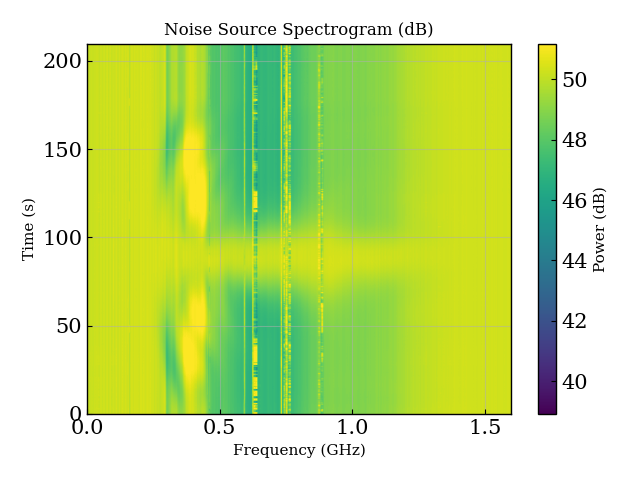

In [47]:
freq_min, freq_max= 0.0, 1.6
time_min, time_max = 0.0, 2500*0.08388608  
plt.figure()
img = plt.imshow(10*np.log10(np.abs(noise_source1[:,:])), extent=[freq_min, freq_max, time_min, time_max], aspect='auto', origin='lower', cmap='viridis')
plt.xlabel("Frequency (GHz)", fontsize=11)
plt.ylabel("Time (s)", fontsize=11)
plt.title("Noise Source Spectrogram (dB)", fontsize=12)
cbar = plt.colorbar(img)
cbar.set_label("Power (dB)", fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_31955/3788910154.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(img)


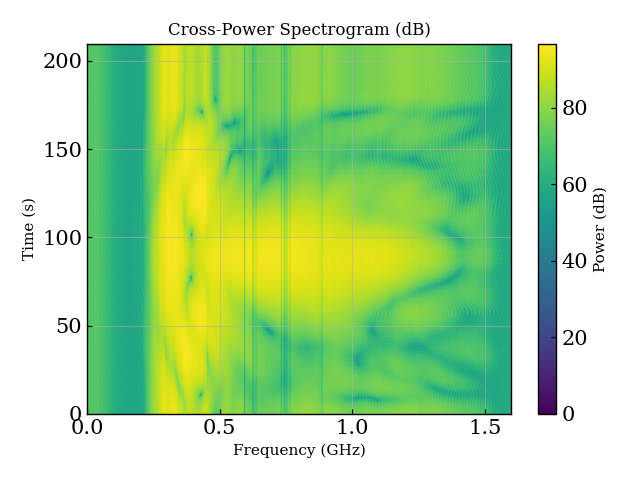

In [95]:
freq_min, freq_max= 0.0, 1.6
time_min, time_max = 0.0, 2500*0.08388608  
plt.figure()
img = plt.imshow(20*np.log10(np.abs(corr_ref1[:,:])), extent=[freq_min, freq_max, time_min, time_max], aspect='auto', origin='lower', cmap='viridis')
plt.xlabel("Frequency (GHz)", fontsize=11)
plt.ylabel("Time (s)", fontsize=11)
plt.title("Cross-Power Spectrogram (dB)", fontsize=12)
cbar = plt.colorbar(img)
cbar.set_label("Power (dB)", fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_31955/2391544515.py:4: RuntimeWarning: divide by zero encountered in log10
  img = plt.imshow(20*np.log10(np.abs(corr_ref2[:,:])), extent=[freq_min, freq_max, time_min, time_max], aspect='auto', origin='lower', cmap='viridis')
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_31955/2391544515.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(img)


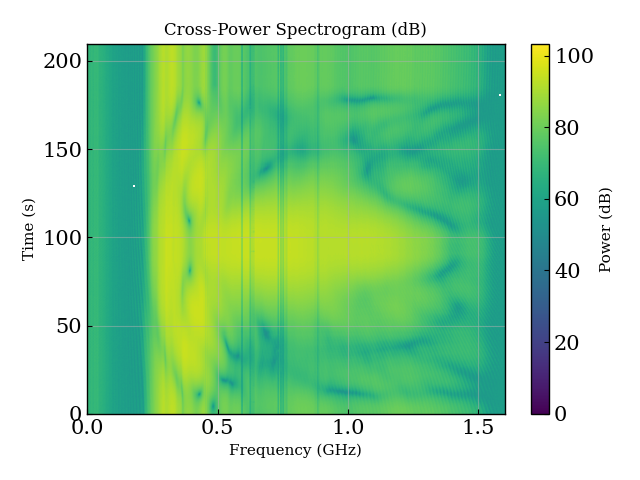

In [273]:
freq_min, freq_max= 0.0, 1.6
time_min, time_max = 0.0, 2500*0.08388608  
plt.figure()
img = plt.imshow(20*np.log10(np.abs(corr_ref2[:,:])), extent=[freq_min, freq_max, time_min, time_max], aspect='auto', origin='lower', cmap='viridis')
plt.xlabel("Frequency (GHz)", fontsize=11)
plt.ylabel("Time (s)", fontsize=11)
plt.title("Cross-Power Spectrogram (dB)", fontsize=12)
cbar = plt.colorbar(img)
cbar.set_label("Power (dB)", fontsize=11)

plt.tight_layout()
plt.show()

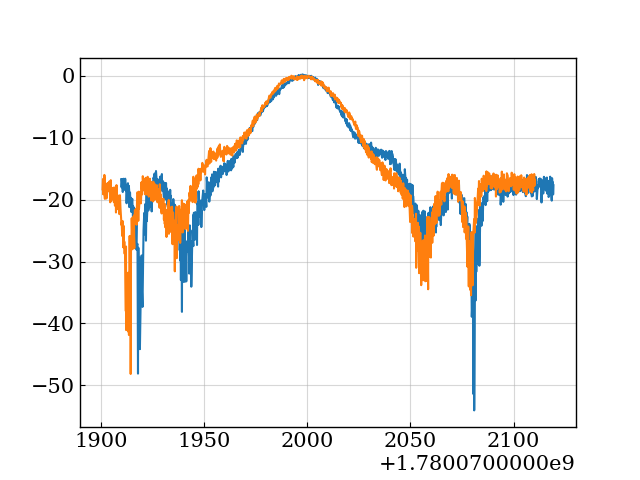

In [264]:
plt.figure()
plt.plot(times1[:2499]+9,20*np.log10(np.abs(corr_ref1[:2499,2055+6*511]))-93.3) # time index offset applied 
plt.plot(times1[:2499],20*np.log10(np.abs(corr_ref2[:2499,2055+6*511]))-92.5)
plt.show()

In [ ]:
time_bins = np.arange(2499)
time_seconds = time_bins*0.08388608 
total_rotation_deg = 360
total_duration = 209.7152

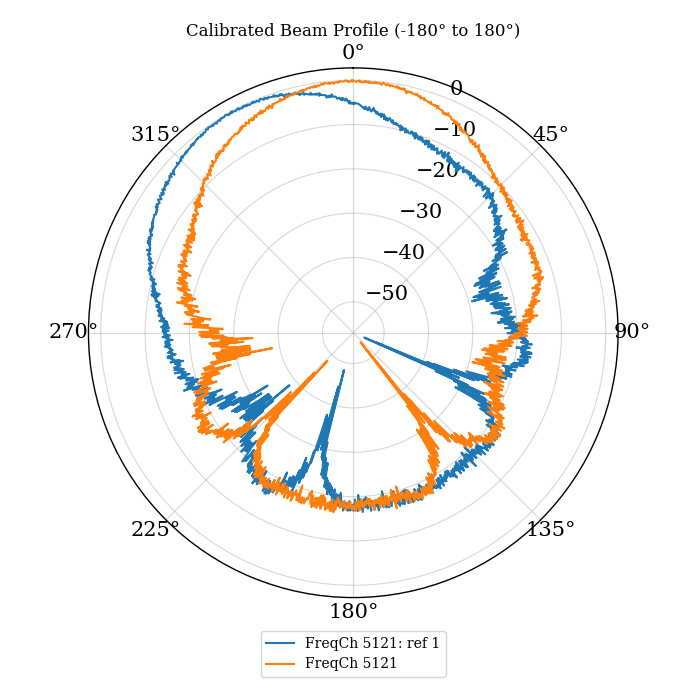

In [204]:
# Maps t=0 to -180° and t=209.7152 to +180°
degrees = (time_seconds * (total_rotation_deg/total_duration)) - 180
theta_rad = degrees * (np.pi / 180.0) 

plt.figure(figsize=(7,7))
ax = plt.subplot(111, projection='polar')
ax.plot(theta_rad, 20*np.log10(np.abs(corr_ref1[:2499,2055+6*511]))-93.5, label=f"FreqCh {2055+6*511}: ref 1")
# Offset to zero the beam profile -- 
ax.plot(theta_rad+0.5, 20*np.log10(np.abs(corr_ref1[:2499,2055+6*511]))-93.5, label="FreqCh 5121") # 0.5*(180/np.pi) = 28.65°
plt.legend(bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=1, fontsize=10)

ax.set_theta_zero_location("N") # Placing  0° at the Top (North)
ax.set_theta_direction(-1) # Clockwise sweep (-180° left, +180° right)

plt.title("Calibrated Beam Profile (-180° to 180°)", fontsize=12)
plt.tight_layout()
plt.show()

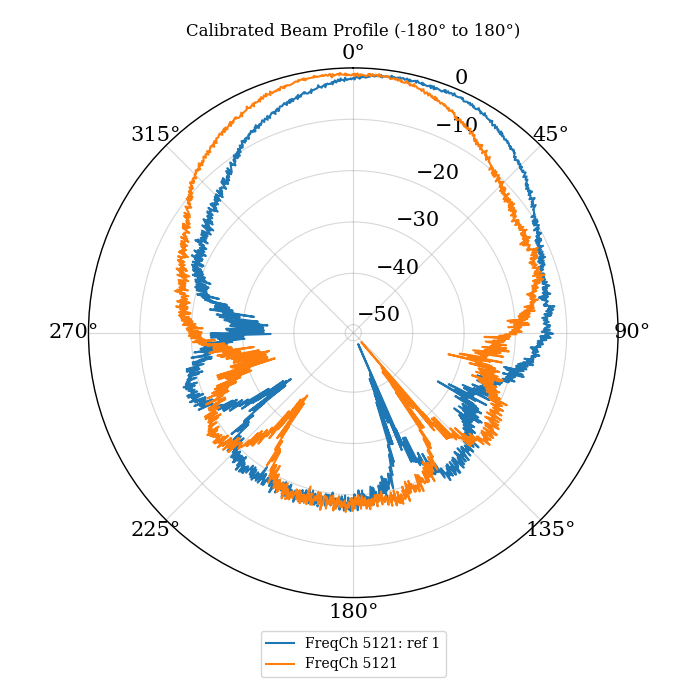

In [205]:
# Flip the sign of the rotation scaling to count down from +180 to -180 -- 
# Old: (time_seconds * factor) - 180
# New: 180 - (time_seconds * (total_rotation_deg / total_duration))
degrees = 180 - (time_seconds * (total_rotation_deg/total_duration))
theta_rad = degrees * (np.pi / 180.0) 

plt.figure(figsize=(7,7))
ax = plt.subplot(111, projection='polar')
ax.plot(theta_rad, 20*np.log10(np.abs(corr_ref2[:2499,2055+6*511]))-93.5, label=f"FreqCh {2055+6*511}: ref 1")
# Offset to zero the beam profile -- 
# Changed offset sign to match the inverted direction of the grid -- 
ax.plot(theta_rad-0.3, 20*np.log10(np.abs(corr_ref2[:2499,2055+6*511]))-93.5, label="FreqCh 5121") # 0.5*(180/np.pi) = 28.65°
plt.legend(bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=1, fontsize=10)

ax.set_theta_zero_location("N") # Placing  0° at the Top (North)
ax.set_theta_direction(-1) # Clockwise sweep (-180° left, +180° right)

plt.title("Calibrated Beam Profile (-180° to 180°)", fontsize=12)
plt.tight_layout()
plt.show()

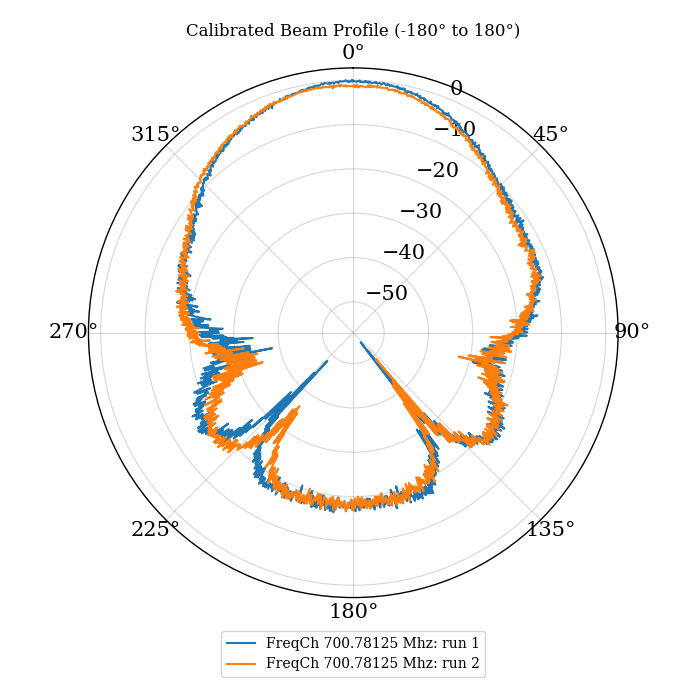

In [223]:
# plotting offset-applied beam profiles for both (-180 to +180) and (+180 to -180) sweeps overlaid -- 
## based on assumption that we used fully utilized total duration for sweep --> not accurate though -- 

degrees = (time_seconds * (total_rotation_deg/total_duration)) - 180
theta_rad = degrees * (np.pi / 180.0) 

degrees_r = 180 - (time_seconds * (total_rotation_deg/total_duration))
theta_rad_r = degrees_r * (np.pi / 180.0) 

plt.figure(figsize=(7,7))
ax = plt.subplot(111, projection='polar')
ax.plot(theta_rad+0.5, 20*np.log10(np.abs(corr_ref1[:2499,2055+6*511]))-93.5, label=f"FreqCh {((2055)+3*511)*(1.6*1e9/8192)*1e-6} Mhz: run 1")
# Offset to zero the beam profile -- 
# Changed offset sign to match the inverted direction of the grid -- 
ax.plot(theta_rad_r-0.3, 20*np.log10(np.abs(corr_ref2[:2499,2055+6*511]))-93.5, label=f"FreqCh {((2055)+3*511)*(1.6*1e9/8192)*1e-6} Mhz: run 2") # 0.5*(180/np.pi) = 28.65°
plt.legend(bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=1, fontsize=10)

ax.set_theta_zero_location("N") # Placing  0° at the Top (North)
ax.set_theta_direction(-1) # Clockwise sweep (-180° left, +180° right)

plt.title("Calibrated Beam Profile (-180° to 180°)", fontsize=12)
plt.tight_layout()
plt.show()

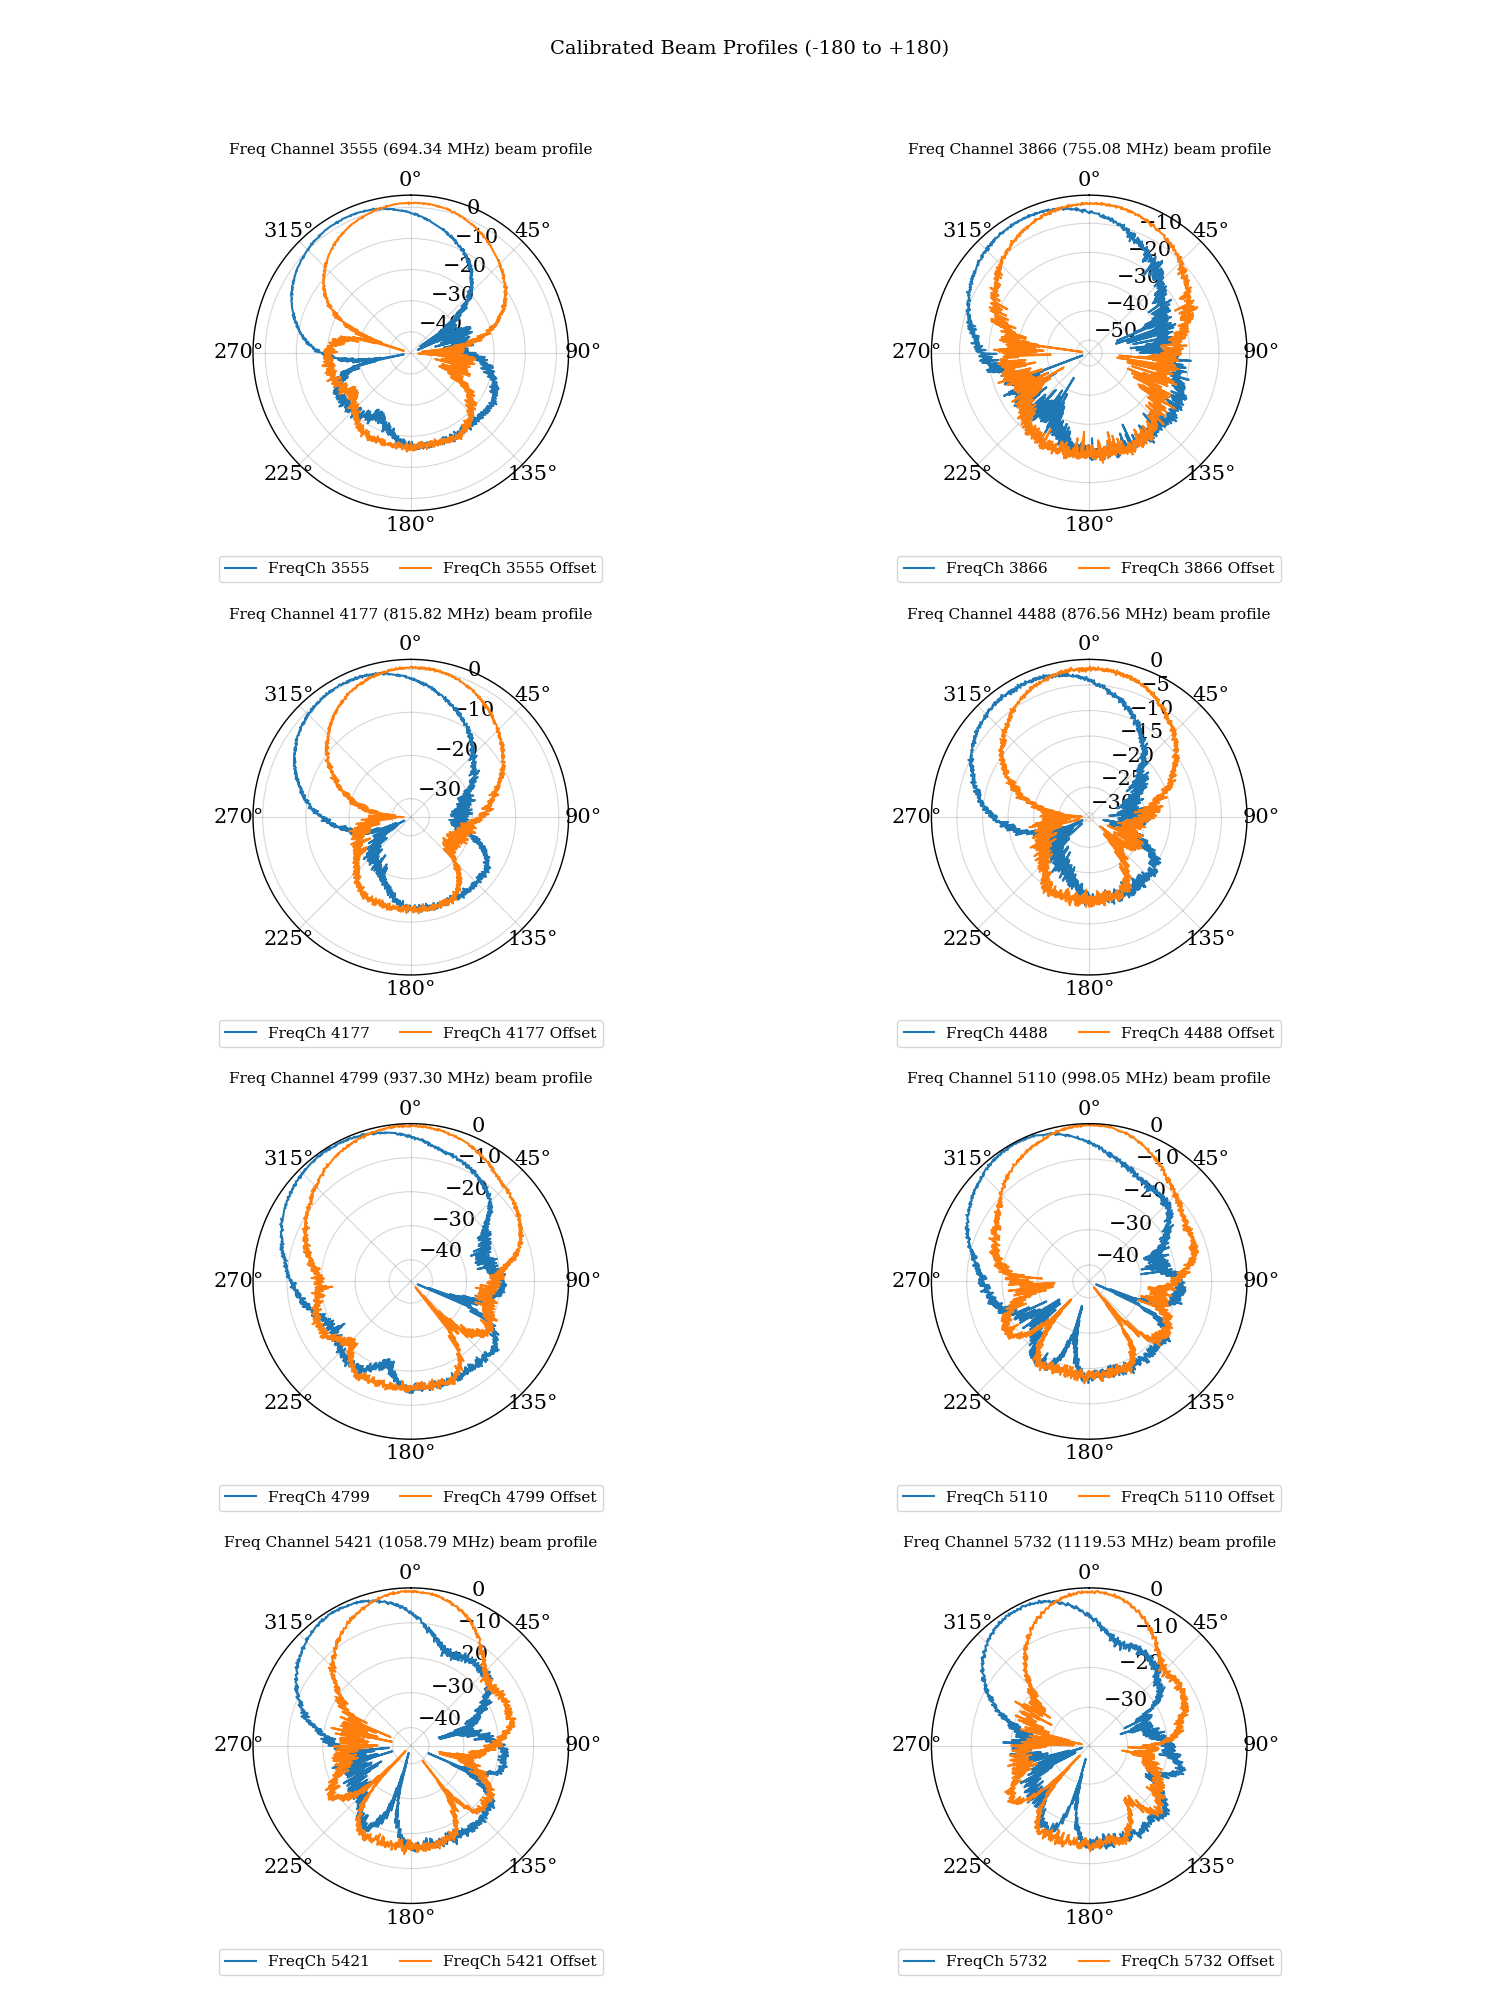

In [238]:

degrees = (time_seconds*(total_rotation_deg/total_duration)) - 180
theta_rad = degrees*(np.pi/180.0) 

channels = [3555+i*311 for i in range(8)]

fig, axes = plt.subplots(4,2, figsize=(15,20), subplot_kw={'projection':'polar'})
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    ch = channels[i]
    
    db_dat = 20*np.log10(np.abs(corr_ref1[:2499,ch]))-93.5
    ax.plot(theta_rad, db_dat, label=f"FreqCh {ch}")
    ax.plot(theta_rad+0.5, db_dat, label=f"FreqCh {ch} Offset")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(f"Freq Channel {ch} ({(3555+i*311)*(1.6*1e9/8192)*1e-6:.2f} MHz) beam profile", fontsize=11, pad=12)
    ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=3, fontsize=11)
    
fig.suptitle("Calibrated Beam Profiles (-180 to +180)", fontsize=14, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

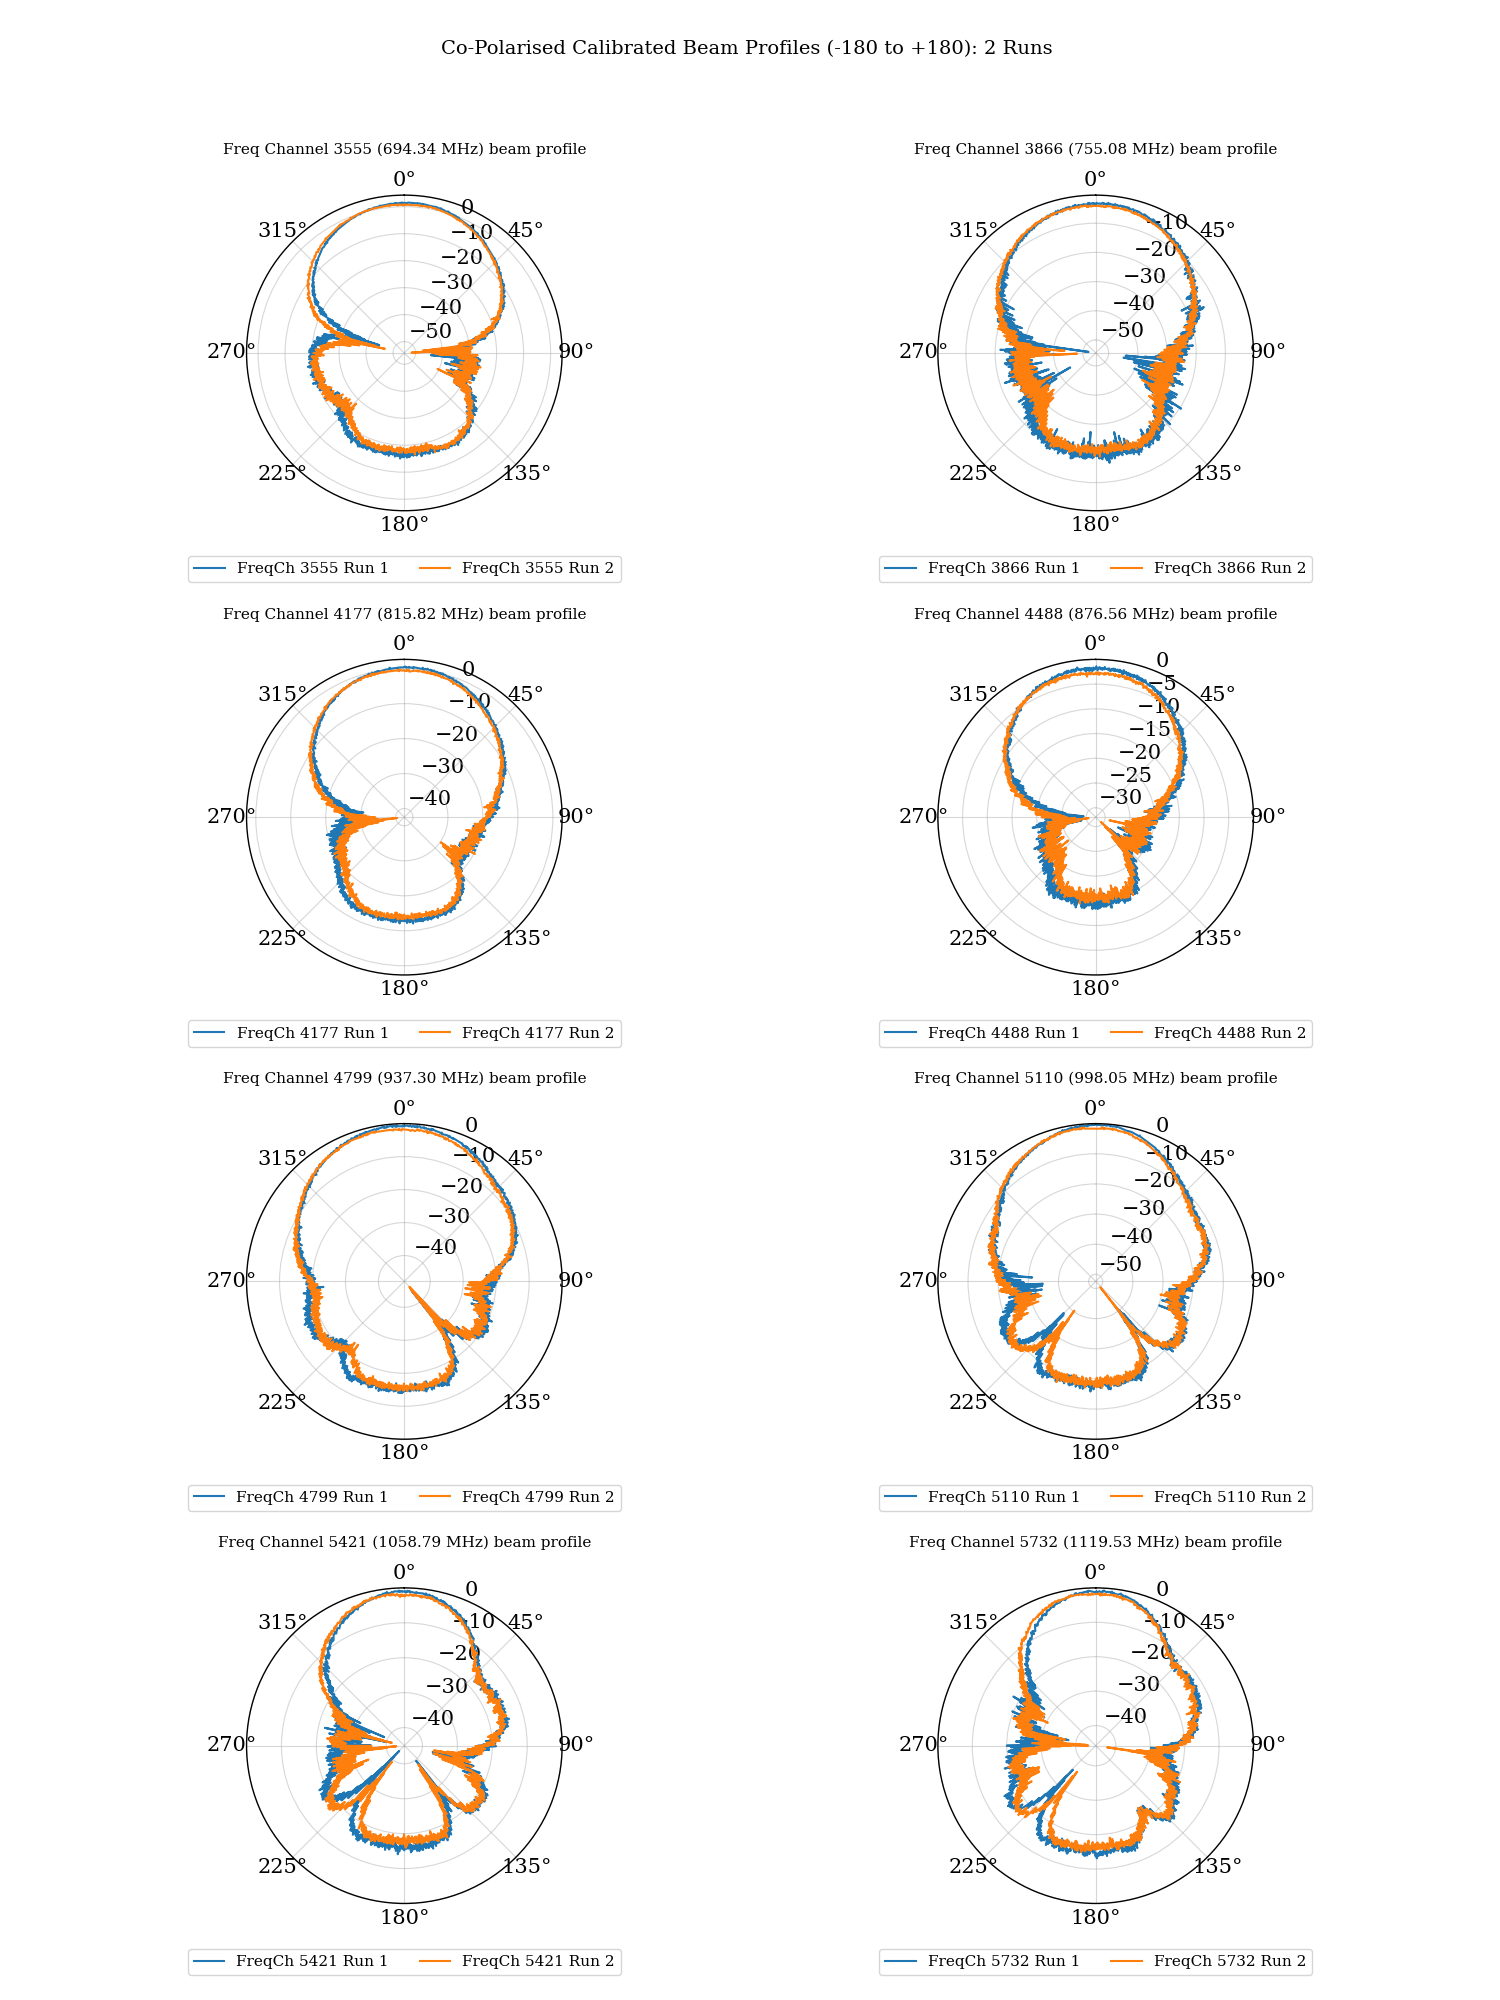

In [282]:
# plotting offset-applied beam profiles for both (-180 to +180) and (+180 to -180) sweeps overlaid -- 
## based on assumption that we used fully utilized total duration for sweep --> not accurate though -- 

degrees = (time_seconds * (total_rotation_deg/total_duration)) - 180
theta_rad = degrees * (np.pi / 180.0) 

degrees_r = 180 - (time_seconds * (total_rotation_deg/total_duration))
theta_rad_r = degrees_r * (np.pi / 180.0) 

channels = [3555+i*311 for i in range(8)]

fig, axes = plt.subplots(4,2, figsize=(15,20), subplot_kw={'projection':'polar'})
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    ch = channels[i]
    
    db_dat1 = 20*np.log10(np.abs(corr_ref1[:2499,ch]))-93.5
    db_dat2 = 20*np.log10(np.abs(corr_ref2[:2499,ch]))-93.5
    ax.plot(theta_rad+0.5, db_dat1, label=f"FreqCh {ch} Run 1")
    ax.plot(theta_rad_r-0.3, db_dat2, label=f"FreqCh {ch} Run 2")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(f"Freq Channel {ch} ({(3555+i*311)*(1.6*1e9/8192)*1e-6:.2f} MHz) beam profile", fontsize=11, pad=12)
    ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=3, fontsize=11)
    
fig.suptitle("Co-Polarised Calibrated Beam Profiles (-180 to +180): 2 Runs ", fontsize=14, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [248]:
## Calculate Point-by-Point Percentage Difference --
# power1 as a baseline reference -- 
power1 = np.abs(corr_ref1)
power2 = np.abs(corr_ref2)

# Percentage difference at every point relative to baseline -- 
pct_diff_profile = np.abs((power1 - power2) / power1) * 100.0
mean_pct_diff = np.mean(pct_diff_profile)
max_pct_diff = np.max(pct_diff_profile)

# R² similarity score --
variance_baseline = np.sum((power1-np.mean(power2))**2)
residual_sum_squares = np.sum((power1-power2)**2)
r2_score = 1.0 - (residual_sum_squares/variance_baseline) if variance_baseline != 0 else 1.0

print(f"--- Beam Profile Discrepancy Analysis ---")
print(f"Average percentage difference: {mean_pct_diff:2f}%")
print(f"Peak (maximum) difference: {max_pct_diff:.2f}%")
print(f"Profile Match Score (R²) : {r2_score * 100:.4f}%")

--- Beam Profile Discrepancy Analysis ---
Average percentage difference: 47.323286%
Peak (maximum) difference: 336009.52%
Profile Match Score (R²) : 89.5773%


## Cross-polarisation (- 180 to +180 deg) and  (180 to -180 deg)
## "Face up": (from receiver antenna POV) TOP clock + patch antenna / LEFT battery on leg / BOTTOM furuno battery / RIGHT attenuator chain (between bico and backplane)

In [268]:
# -180 to +180 deg -- 
f3 = h5py.File("/Users/kalyanibhopi94/crs_chamber_drone_data/20260529-141106_anechoicchamber_corr8/0.hdf5","r") 
# +180 to -180 deg -- 
f4 = h5py.File("/Users/kalyanibhopi94/crs_chamber_drone_data/20260529-142452_anechoicchamber_corr8/0.hdf5","r")

In [269]:
freq_vals = f3['index_map']['freq']
times3 = f3['index_map']['time']
times4 = f4['index_map']['time']
fpga_counts = f3['counts']
corr_data1=f3['vis']
corr_data2=f4['vis']

In [270]:
noise_source3 = f3['vis'][:,:,0] # corr_data[:,:,0]
corr_ref3 = f3['vis'][:,:,1] # corr_data[:,:,1]
ref_auto3 = f3['vis'][:,:,4] # corr_data[:,:,4]

noise_source4 = f4['vis'][:,:,0] # corr_data[:,:,0]
corr_ref4 = f4['vis'][:,:,1] # corr_data[:,:,1]
ref_auto4 = f4['vis'][:,:,4] # corr_data[:,:,4]

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_31955/3994030306.py:4: RuntimeWarning: divide by zero encountered in log10
  img = plt.imshow(20*np.log10(np.abs(corr_ref3[:,:])), extent=[freq_min, freq_max, time_min, time_max], aspect='auto', origin='lower', cmap='viridis')
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_31955/3994030306.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(img)


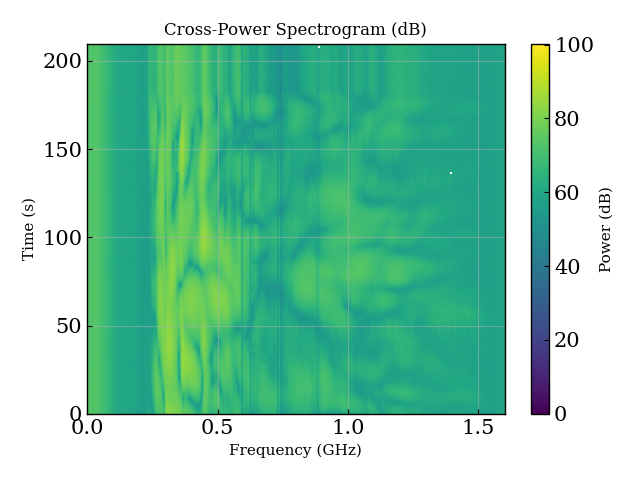

In [271]:
freq_min, freq_max= 0.0, 1.6
time_min, time_max = 0.0, 2500*0.08388608  
plt.figure()
img = plt.imshow(20*np.log10(np.abs(corr_ref3[:,:])), extent=[freq_min, freq_max, time_min, time_max], aspect='auto', origin='lower', cmap='viridis')
plt.xlabel("Frequency (GHz)", fontsize=11)
plt.ylabel("Time (s)", fontsize=11)
plt.title("Cross-Power Spectrogram (dB)", fontsize=12)
cbar = plt.colorbar(img)
cbar.set_label("Power (dB)", fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_31955/1185874243.py:4: RuntimeWarning: divide by zero encountered in log10
  img = plt.imshow(20*np.log10(np.abs(corr_ref4[:,:])), extent=[freq_min, freq_max, time_min, time_max], aspect='auto', origin='lower', cmap='viridis')
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_31955/1185874243.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(img)


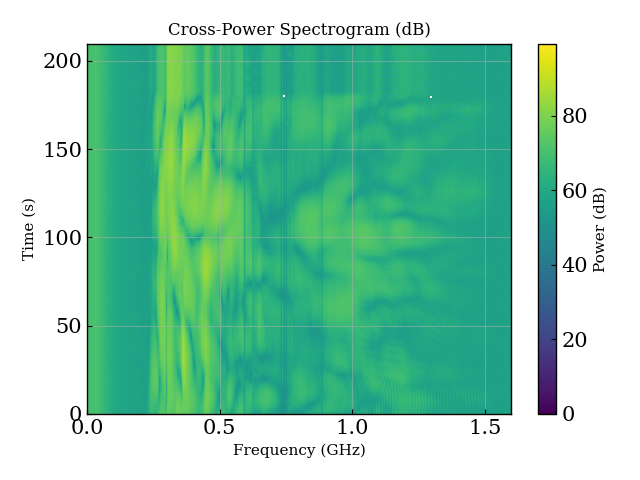

In [272]:
freq_min, freq_max= 0.0, 1.6
time_min, time_max = 0.0, 2500*0.08388608  
plt.figure()
img = plt.imshow(20*np.log10(np.abs(corr_ref4[:,:])), extent=[freq_min, freq_max, time_min, time_max], aspect='auto', origin='lower', cmap='viridis')
plt.xlabel("Frequency (GHz)", fontsize=11)
plt.ylabel("Time (s)", fontsize=11)
plt.title("Cross-Power Spectrogram (dB)", fontsize=12)
cbar = plt.colorbar(img)
cbar.set_label("Power (dB)", fontsize=11)

plt.tight_layout()
plt.show()

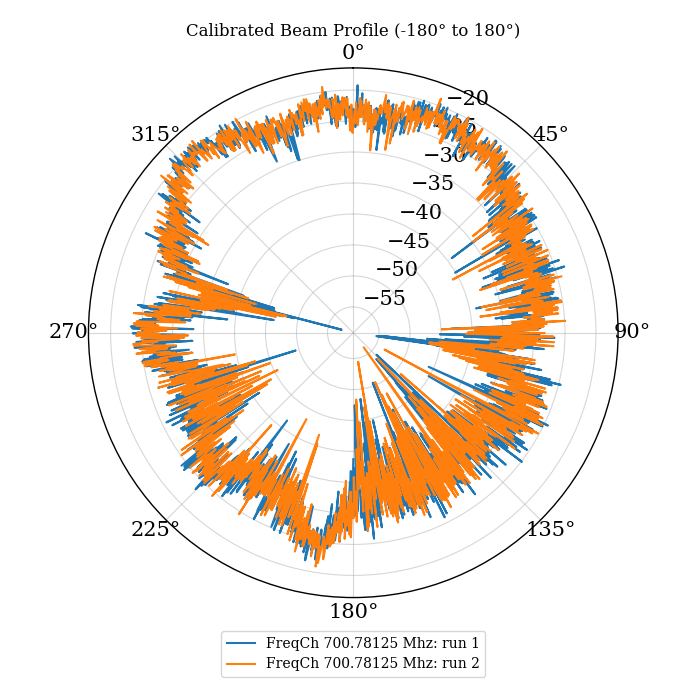

In [279]:
# plotting offset-applied beam profiles for both (-180 to +180) and (+180 to -180) sweeps overlaid -- 
## based on assumption that we used fully utilized total duration for sweep --> not accurate though -- 

degrees = (time_seconds * (total_rotation_deg/total_duration)) - 180
theta_rad = degrees * (np.pi / 180.0) 

degrees_r = 180 - (time_seconds * (total_rotation_deg/total_duration))
theta_rad_r = degrees_r * (np.pi / 180.0) 

plt.figure(figsize=(7,7))
ax = plt.subplot(111, projection='polar')
ax.plot(theta_rad, 20*np.log10(np.abs(corr_ref3[:2499,2055+6*511]))-93.5, label=f"FreqCh {((2055)+3*511)*(1.6*1e9/8192)*1e-6} Mhz: run 1")
# Offset to zero the beam profile -- 
# Changed offset sign to match the inverted direction of the grid -- 
ax.plot(theta_rad_r-0.8, 20*np.log10(np.abs(corr_ref4[:2499,2055+6*511]))-93.5, label=f"FreqCh {((2055)+3*511)*(1.6*1e9/8192)*1e-6} Mhz: run 2") # 0.5*(180/np.pi) = 28.65°
plt.legend(bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=1, fontsize=10)

ax.set_theta_zero_location("N") # Placing  0° at the Top (North)
ax.set_theta_direction(-1) # Clockwise sweep (-180° left, +180° right)

plt.title("Calibrated Beam Profile (-180° to 180°)", fontsize=12)
plt.tight_layout()
plt.show()

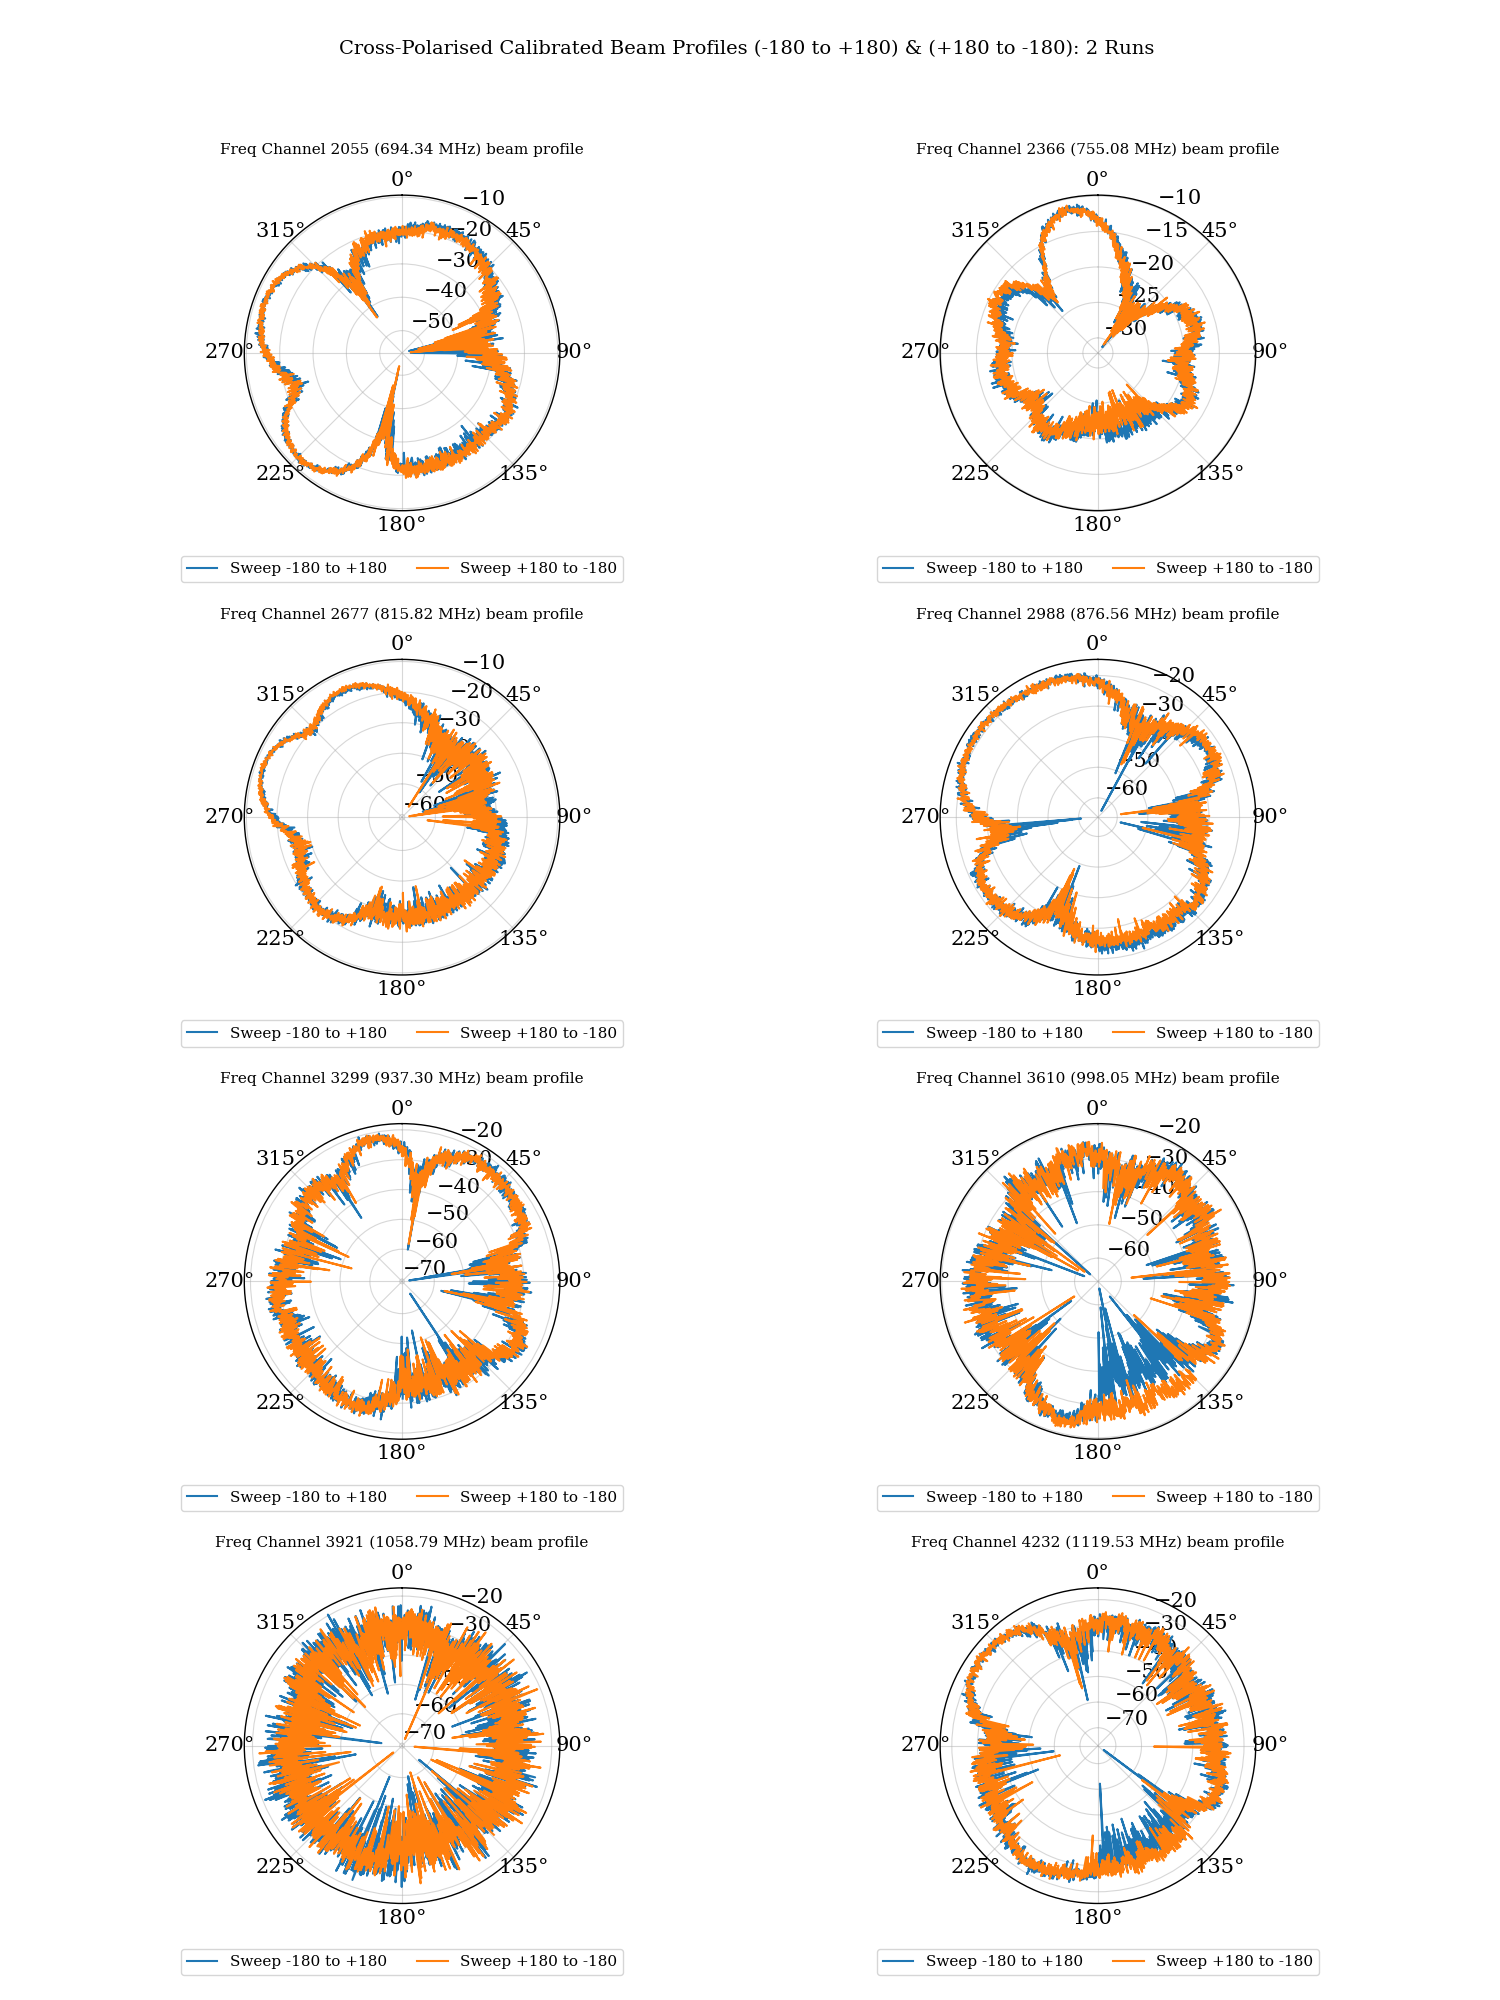

In [287]:
# plotting offset-applied beam profiles for both (-180 to +180) and (+180 to -180) sweeps overlaid -- 
## based on assumption that we used fully utilized total duration for sweep --> not accurate though -- 

degrees = (time_seconds * (total_rotation_deg/total_duration)) - 180
theta_rad = degrees * (np.pi / 180.0) 

degrees_r = 180 - (time_seconds * (total_rotation_deg/total_duration))
theta_rad_r = degrees_r * (np.pi / 180.0) 

channels = [2055+i*311 for i in range(8)]

fig, axes = plt.subplots(4,2, figsize=(15,20), subplot_kw={'projection':'polar'})
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    ch = channels[i]
    
    db_dat1 = 20*np.log10(np.abs(corr_ref3[:2499,ch]))-93.5
    db_dat2 = 20*np.log10(np.abs(corr_ref4[:2499,ch]))-93.5
    ax.plot(theta_rad, db_dat1, label=f"Sweep -180 to +180")
    ax.plot(theta_rad_r-0.8, db_dat2, label=f"Sweep +180 to -180")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(f"Freq Channel {ch} ({(3555+i*311)*(1.6*1e9/8192)*1e-6:.2f} MHz) beam profile", fontsize=11, pad=12)
    ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=3, fontsize=11)
    
fig.suptitle("Cross-Polarised Calibrated Beam Profiles (-180 to +180) & (+180 to -180): 2 Runs ", fontsize=14, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()